In [1]:
import pandas as pd


In [2]:
X_train_selected=pd.read_csv('X_train_selected.csv')
X_test_selected=pd.read_csv('X_test_selected.csv')
y_train=pd.read_csv('y_train_trrrrr.csv')
y_test=pd.read_csv('y_test_triii.csv')

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef, ConfusionMatrixDisplay


In [4]:
# Load the dataset
X_train = pd.read_csv('X_train_selected.csv')
X_test = pd.read_csv('X_test_selected.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(299, 8) (75, 8) (299, 1) (75, 1)


In [5]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()


In [6]:
X_train.columns

Index(['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
       'Stress Level', 'Heart Rate', 'Daily Steps', 'Occupation_Salesperson'],
      dtype='object')

In [7]:
X_train.isnull().sum()

Age                        0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
Heart Rate                 0
Daily Steps                0
Occupation_Salesperson     0
dtype: int64

In [8]:
pd.Series(y_train).value_counts()


Sleep Apnea    238
Insomnia        61
Name: count, dtype: int64

In [9]:
pd.Series(y_test).value_counts()


Sleep Apnea    59
Insomnia       16
Name: count, dtype: int64

Model: SVC

Training Performance:
Accuracy:  0.9431
Precision: 0.9430
Recall:    0.9431
F1 Score:  0.9410
MCC:       0.8184

Test Performance:
Accuracy:  0.9200
Precision: 0.9179
Recall:    0.9200
F1 Score:  0.9180
MCC:       0.7529


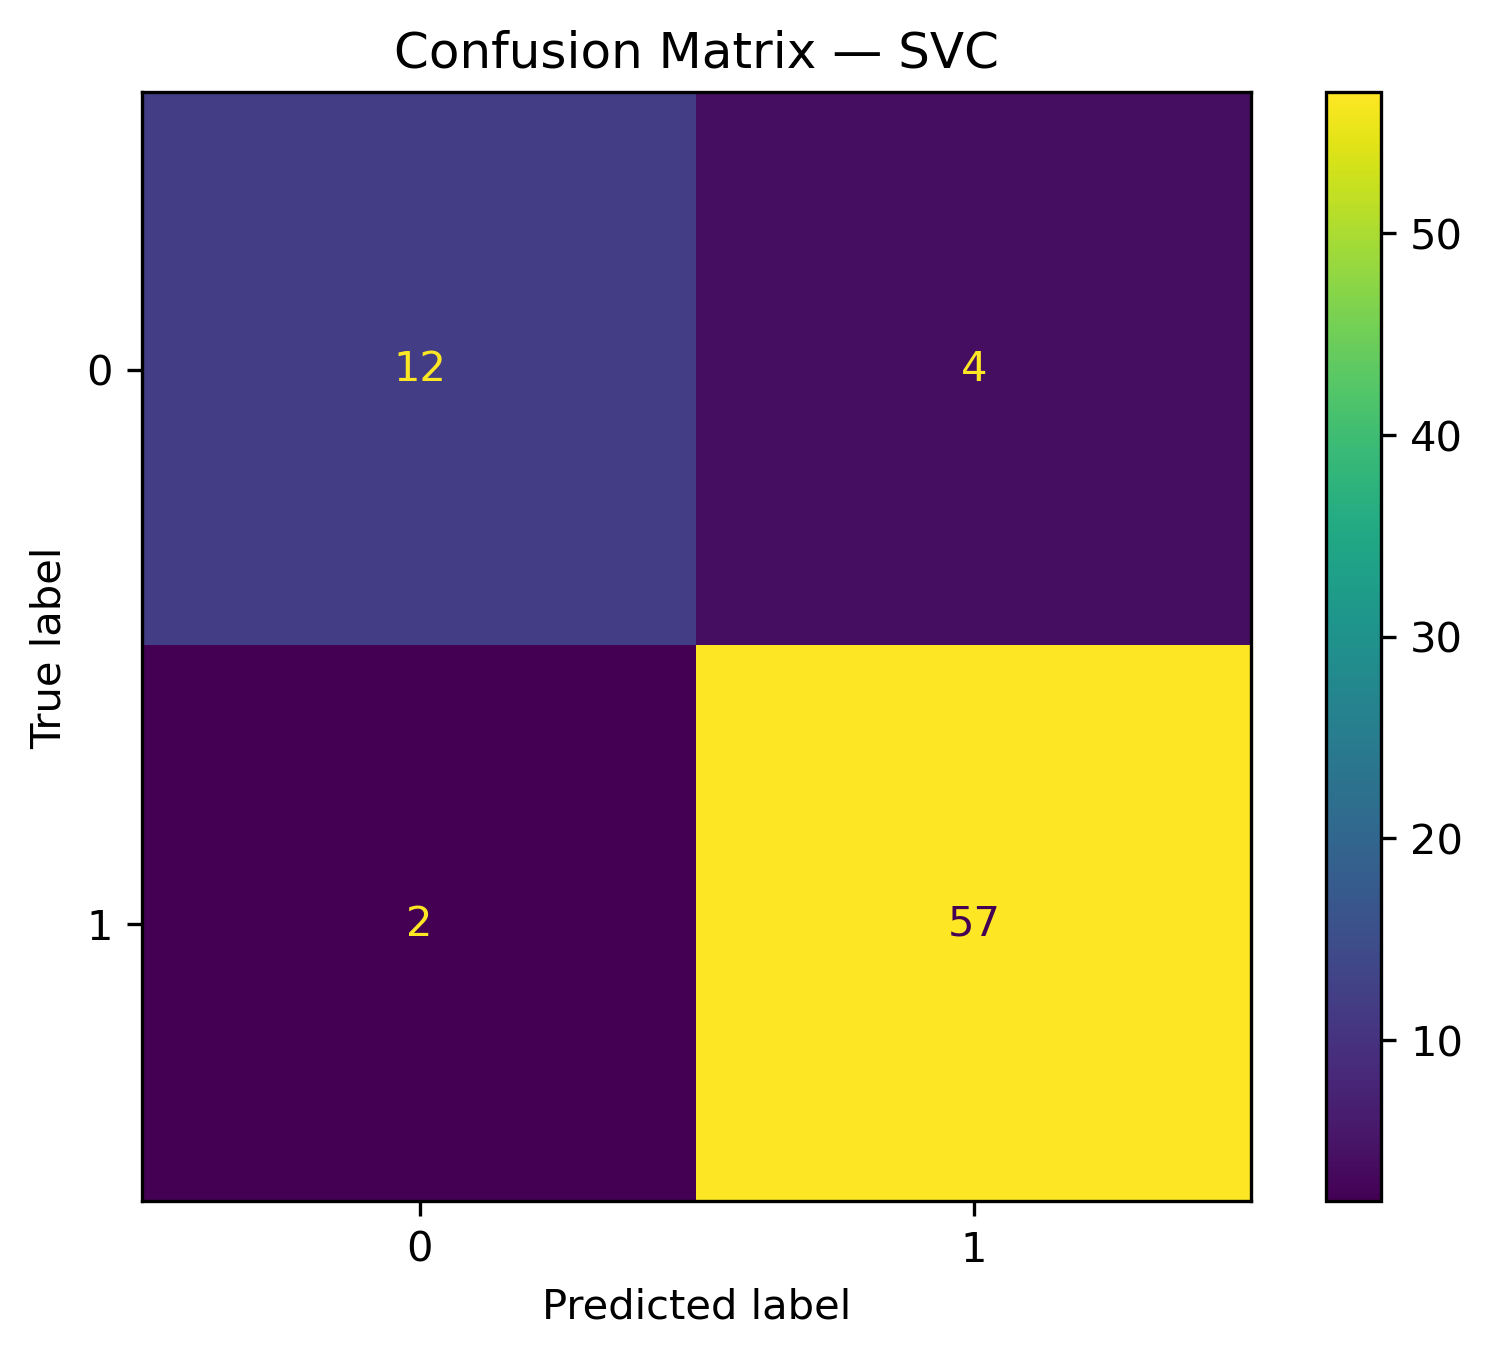

Model: DecisionTree

Training Performance:
Accuracy:  0.9666
Precision: 0.9663
Recall:    0.9666
F1 Score:  0.9663
MCC:       0.8959

Test Performance:
Accuracy:  0.8933
Precision: 0.8993
Recall:    0.8933
F1 Score:  0.8956
MCC:       0.6981


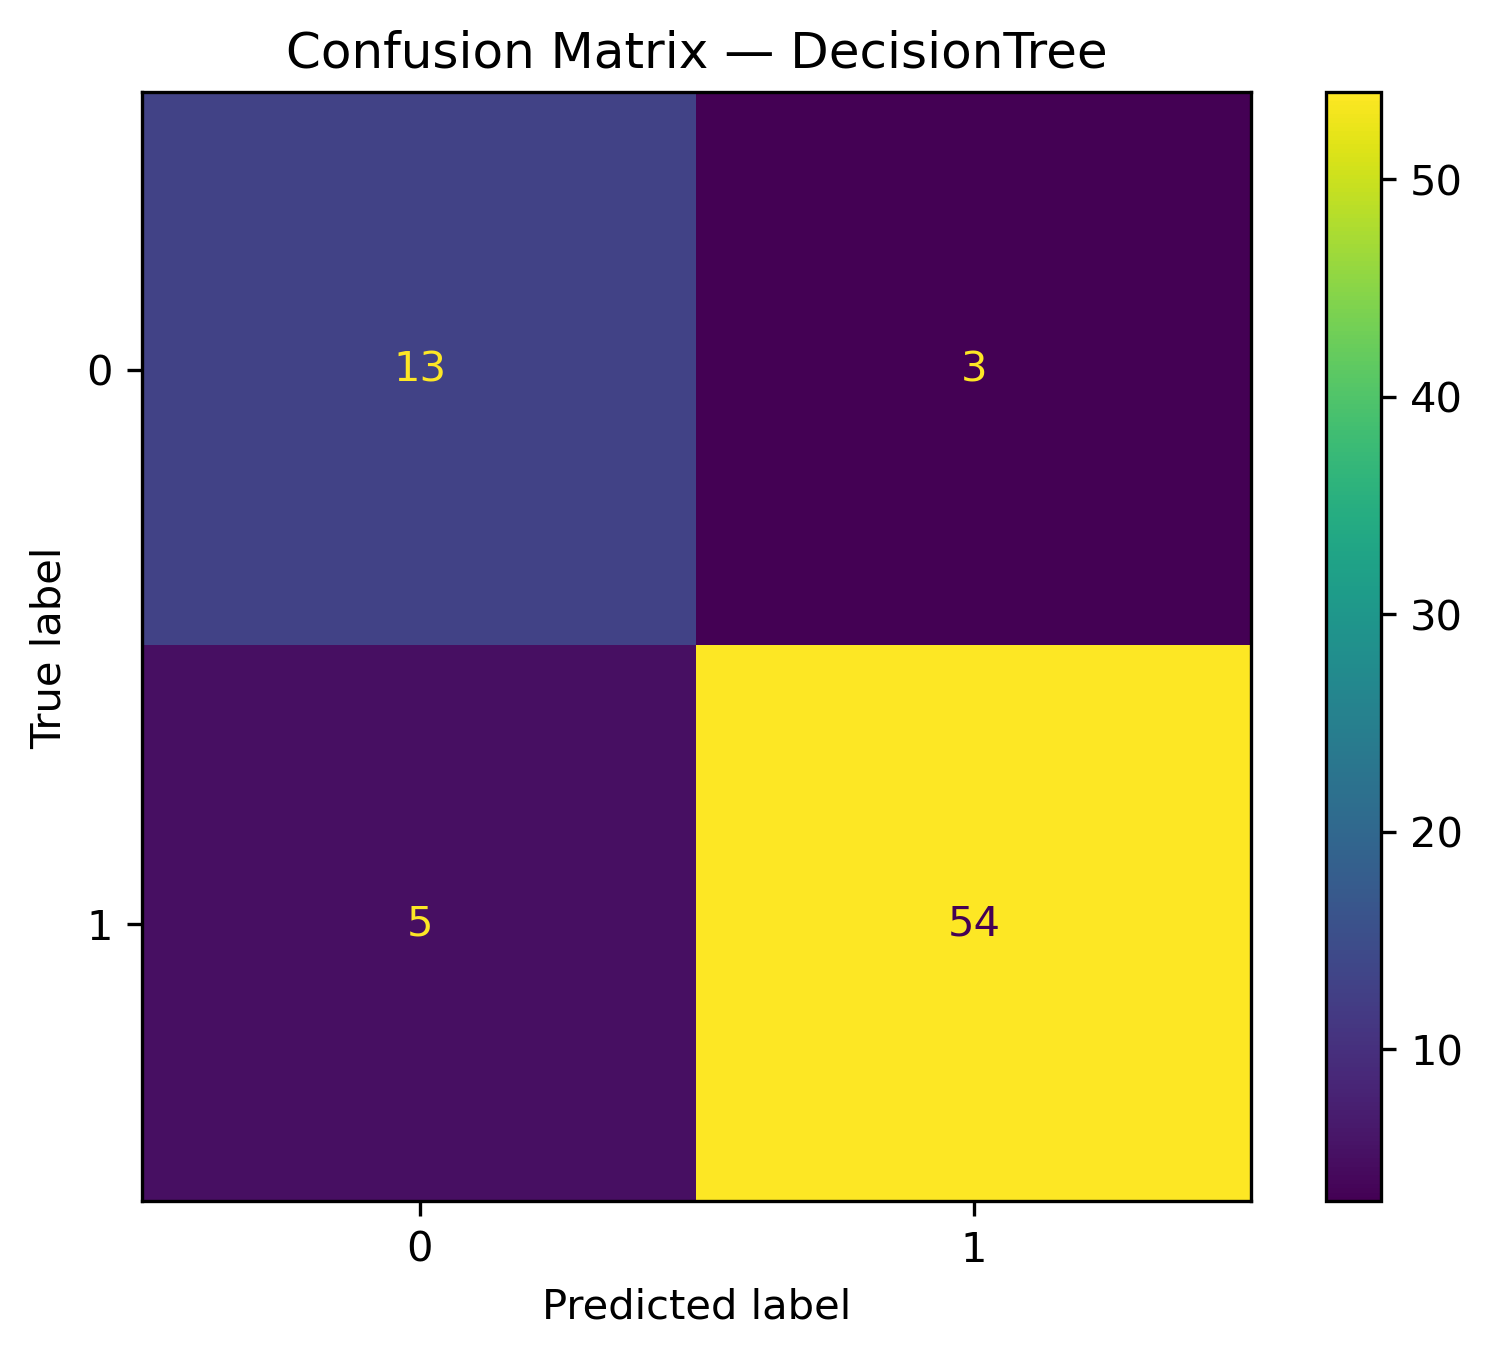

Model: GradientBoosting

Training Performance:
Accuracy:  0.9666
Precision: 0.9663
Recall:    0.9666
F1 Score:  0.9663
MCC:       0.8959

Test Performance:
Accuracy:  0.8933
Precision: 0.8993
Recall:    0.8933
F1 Score:  0.8956
MCC:       0.6981


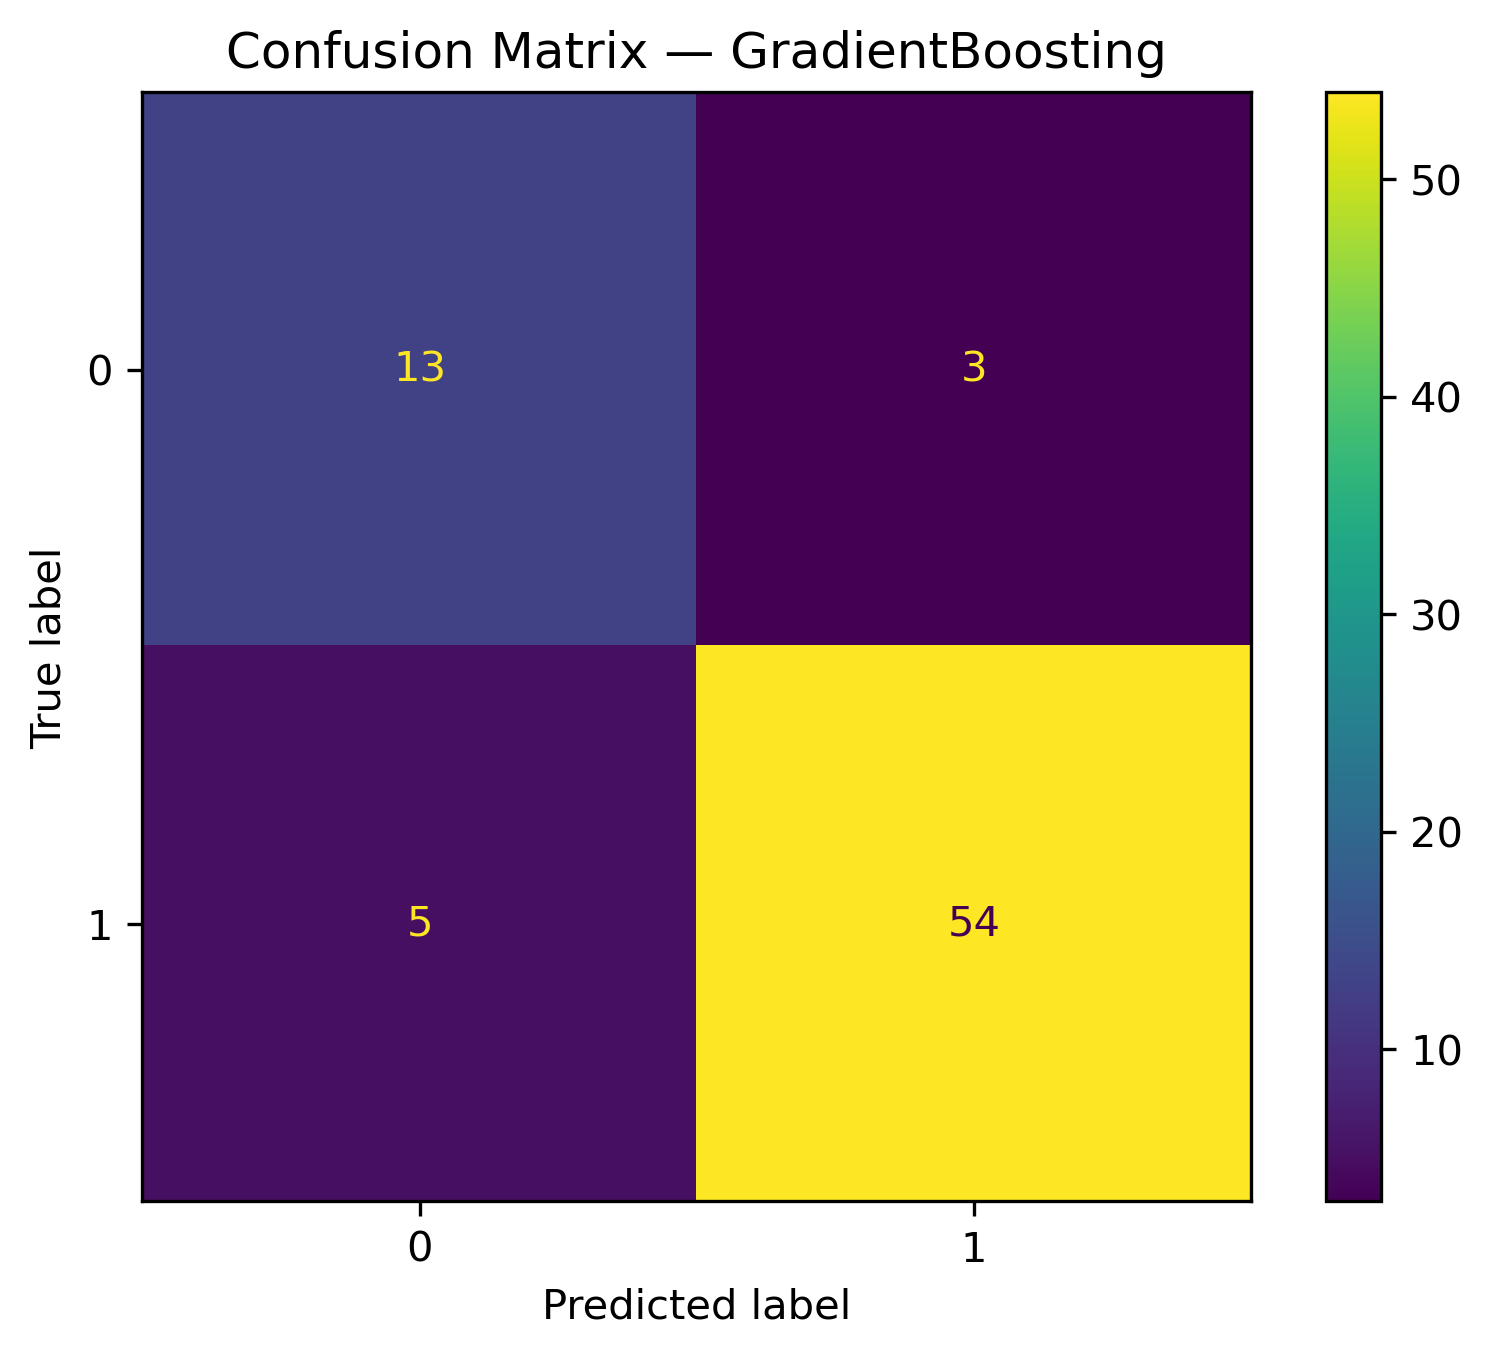

Model: Bagging (SVC base)

Training Performance:
Accuracy:  0.9431
Precision: 0.9430
Recall:    0.9431
F1 Score:  0.9410
MCC:       0.8184

Test Performance:
Accuracy:  0.9200
Precision: 0.9179
Recall:    0.9200
F1 Score:  0.9180
MCC:       0.7529


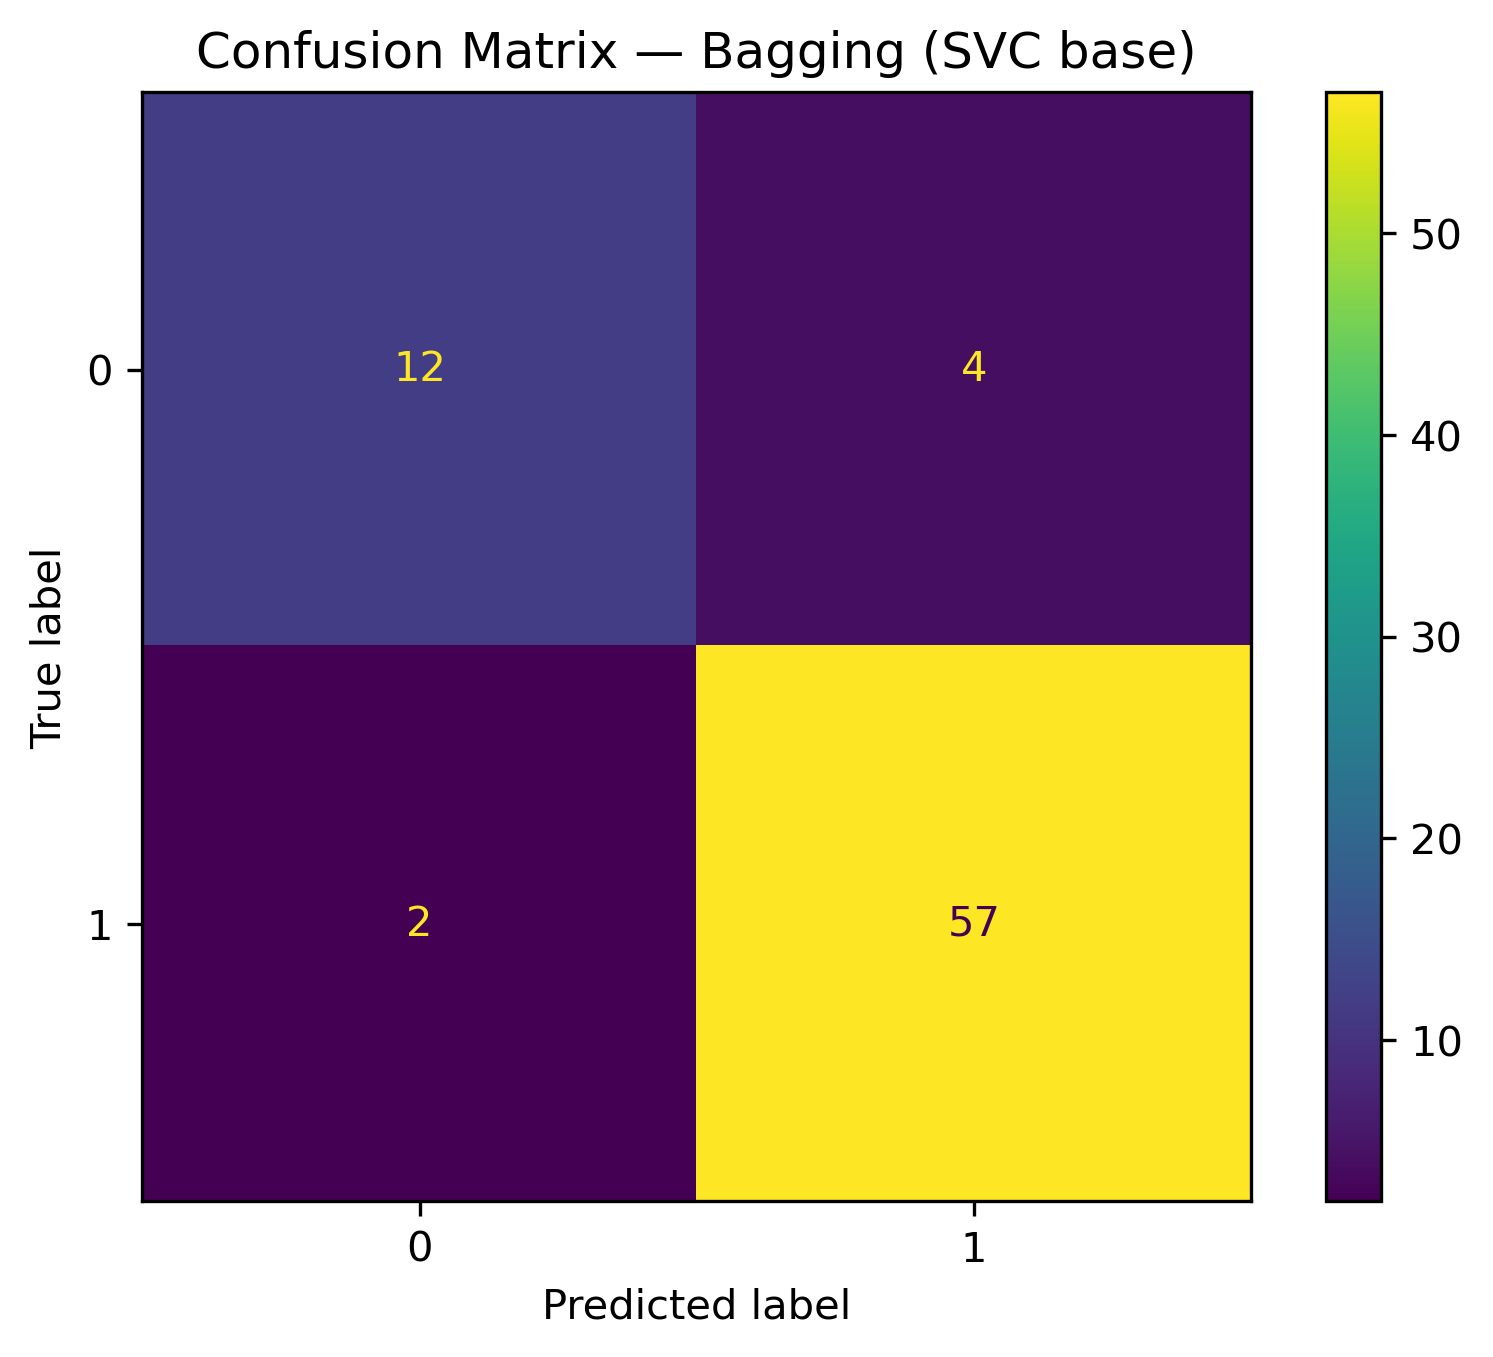

Model: RandomForest

Training Performance:
Accuracy:  0.9666
Precision: 0.9662
Recall:    0.9666
F1 Score:  0.9661
MCC:       0.8952

Test Performance:
Accuracy:  0.8933
Precision: 0.8993
Recall:    0.8933
F1 Score:  0.8956
MCC:       0.6981


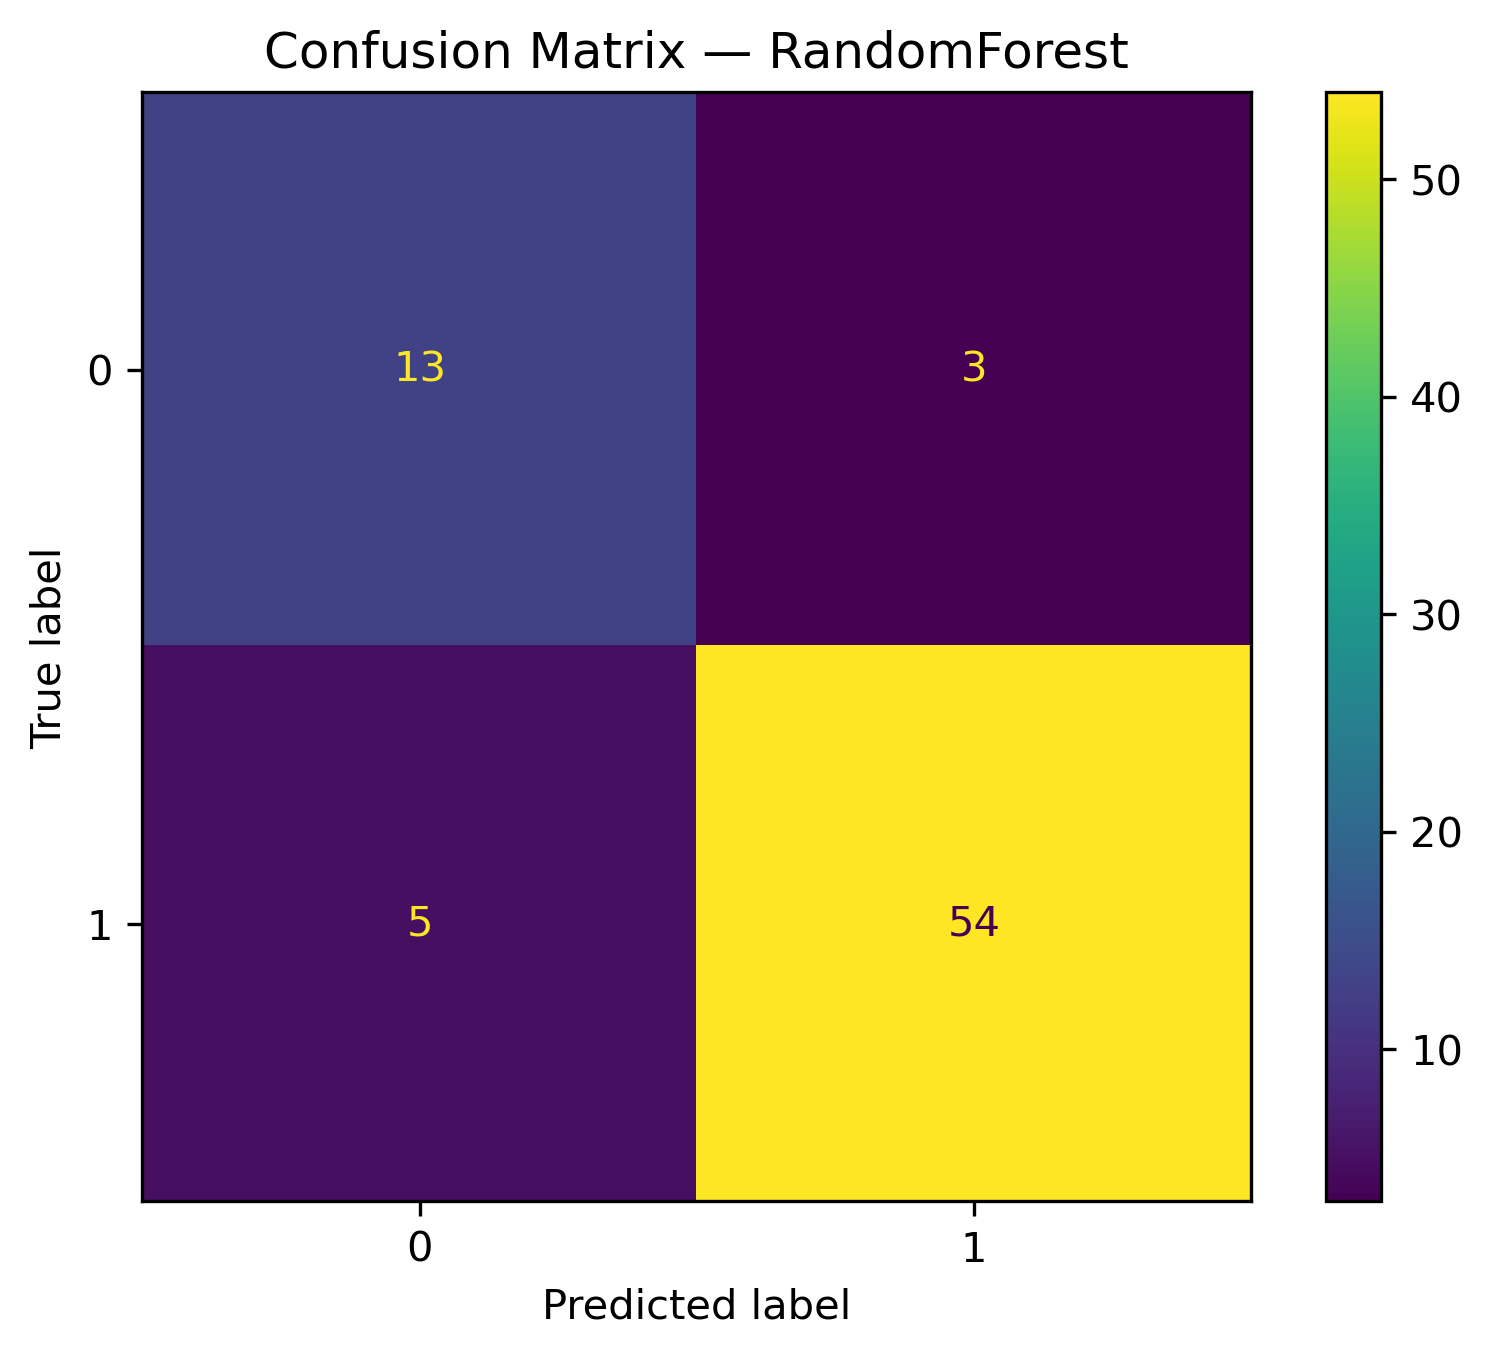

Model: Stacking

Training Performance:
Accuracy:  0.9666
Precision: 0.9662
Recall:    0.9666
F1 Score:  0.9661
MCC:       0.8952

Test Performance:
Accuracy:  0.8800
Precision: 0.8830
Recall:    0.8800
F1 Score:  0.8813
MCC:       0.6509


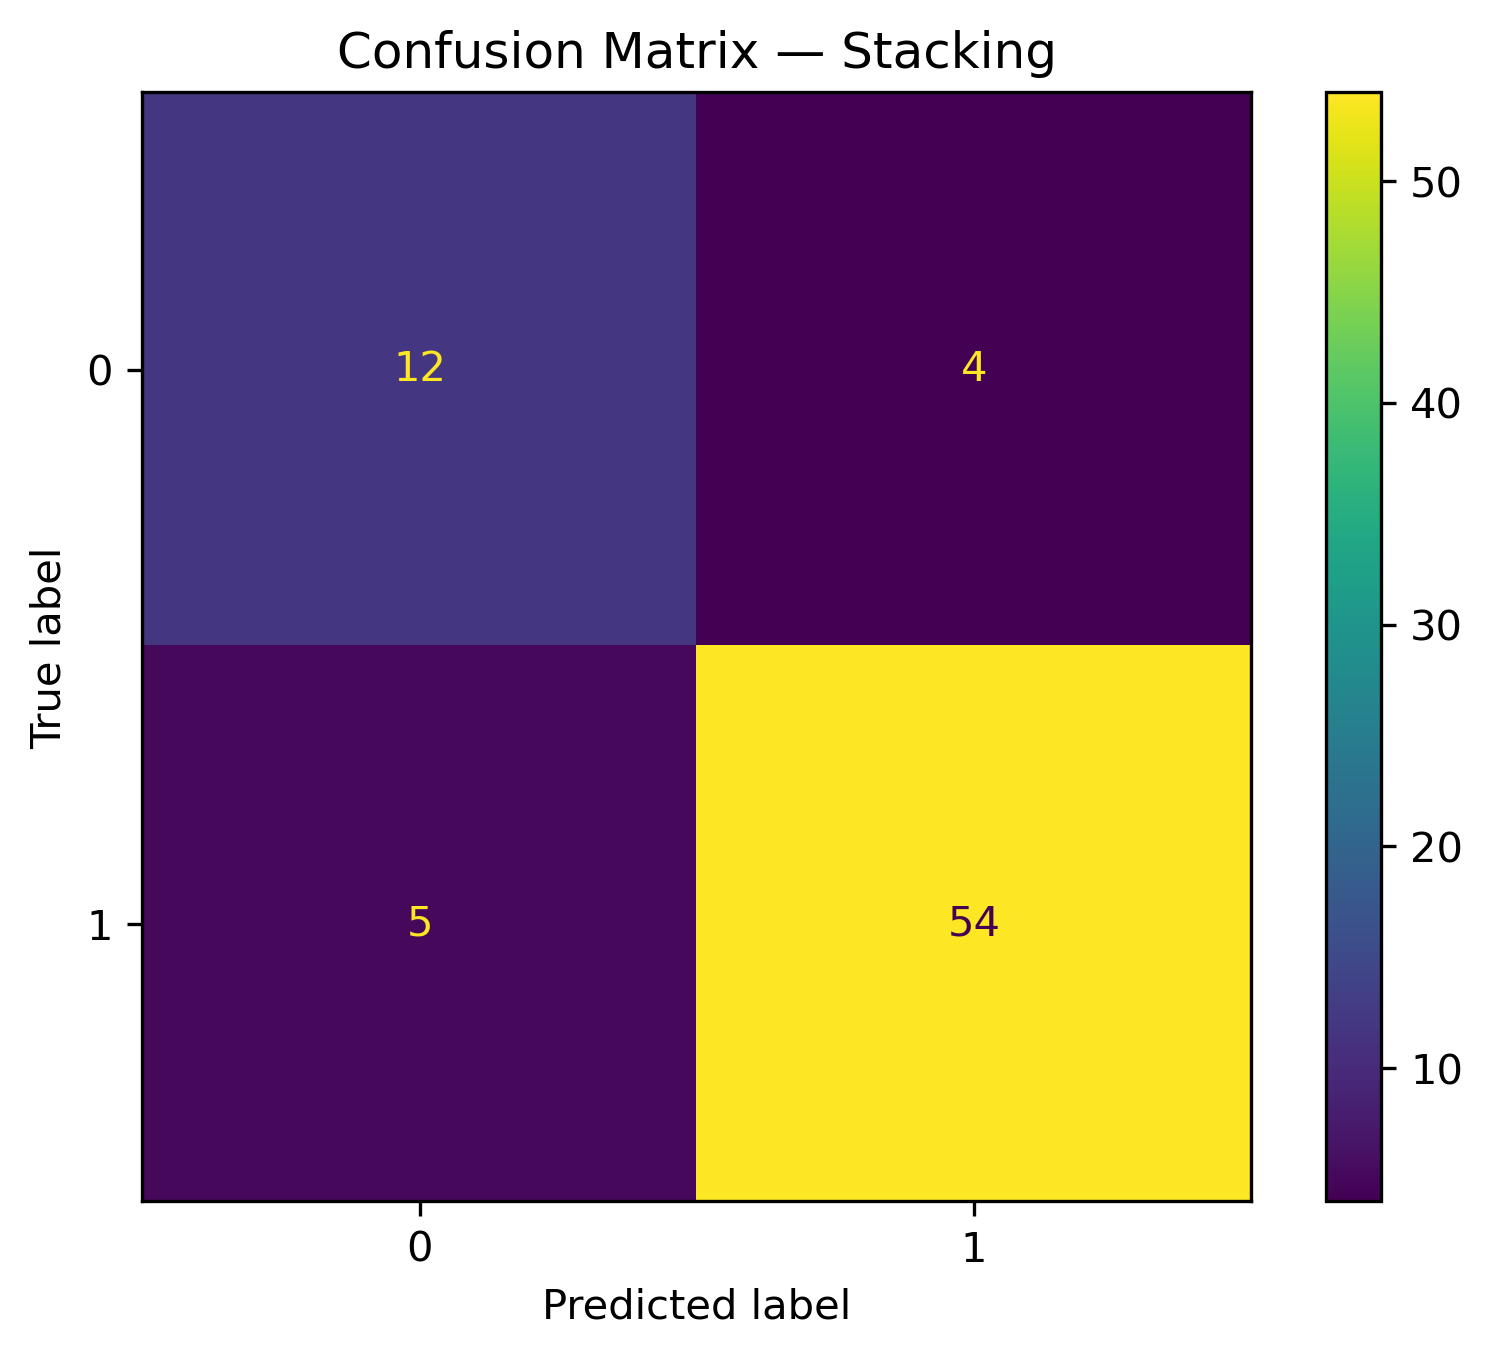

In [10]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

# ======================
# Define all models
# ======================
models = {
    "SVC": SVC(kernel='rbf', random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "Bagging (SVC base)": BaggingClassifier(estimator=SVC(kernel='rbf'),random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "Stacking": StackingClassifier(
        estimators=[
            ('gb', GradientBoostingClassifier(random_state=42)),
            ('svc', SVC(kernel='rbf', random_state=42)),
            ('rf', RandomForestClassifier(random_state=42))
        ],
        final_estimator=DecisionTreeClassifier(random_state=42)
    )
}

# ======================
# Train & Evaluate
# ======================
for name, clf in models.items():
    print("="*60)
    print(f"Model: {name}")
    clf.fit(X_train, y_train)

    # Predictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    # Training metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred,average='weighted')
    train_rec = recall_score(y_train, y_train_pred,average='weighted')
    train_f1 = f1_score(y_train, y_train_pred,average='weighted')
    train_mcc = matthews_corrcoef(y_train, y_train_pred)

    # Test metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred,average='weighted')
    test_rec = recall_score(y_test, y_test_pred,average='weighted')
    test_f1 = f1_score(y_test, y_test_pred,average='weighted')
    test_mcc = matthews_corrcoef(y_test, y_test_pred)

    # Print results
    print("\nTraining Performance:")
    print(f"Accuracy:  {train_acc:.4f}")
    print(f"Precision: {train_prec:.4f}")
    print(f"Recall:    {train_rec:.4f}")
    print(f"F1 Score:  {train_f1:.4f}")
    print(f"MCC:       {train_mcc:.4f}")

    print("\nTest Performance:")
    print(f"Accuracy:  {test_acc:.4f}")
    print(f"Precision: {test_prec:.4f}")
    print(f"Recall:    {test_rec:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"MCC:       {test_mcc:.4f}")

    # Confusion Matrix (Test)
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.show()
